## Multi-Concept Top-k Concept Guided Decoding

Comparison of three generation modes:
- **No steering** (baseline): standard greedy generation.
- **Single-concept steering**: existing CGD with one concept pair (A − B).
- **Multi-concept steering**: two concept pairs composed via `linear` or `subspace` fusion.

In [1]:
import pandas as pd

from frames.representations import FrameUnembeddingRepresentation
from frames.nlp.datasets import load_multilingual_question_dataset
from frames.utils.plotting import lineplot_and_save

In [2]:
# parameters
MODEL_ID = "hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4"
N = 256
STEPS = 32
BATCH_SIZE = 16
K = 3
MIN_LEMMAS = 3
MAX_TOKENS = 3

# concept pairs: each (A, B) produces a directional guide A − B
CONCEPT_PAIRS = [
    ("woman.n.01", "man.n.01"),
    ("science.n.01", "art.n.01"),
]

MODES = ["linear", "subspace"]

# weight sweep for linear mode: (weight_pair_0, weight_pair_1)
WEIGHTS_SWEEP = [(1.0, 0.0), (0.7, 0.3), (0.5, 0.5), (0.3, 0.7), (0.0, 1.0)]

X = "token index"
Y = "total projection"
HUE = "condition"

In [3]:
fur = FrameUnembeddingRepresentation.from_model_id(MODEL_ID)

Token has not been saved to git credential helper.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


/home/rodrigo/projects/frh-multi/.venv/lib/python3.11/site-packages/awq/__init__.py:21: DeprecationWarning: 
I have left this message as the final dev message to help you transition.

Important Notice:
- AutoAWQ is officially deprecated and will no longer be maintained.
- The last tested configuration used Torch 2.6.0 and Transformers 4.51.3.
- If future versions of Transformers break AutoAWQ compatibility, please report the issue to the Transformers project.

Alternative:
- AutoAWQ has been adopted by the vLLM Project: https://github.com/vllm-project/llm-compressor

For further inquiries, feel free to reach out:
- X: https://x.com/casper_hansen_
- LinkedIn: https://www.linkedin.com/in/casper-hansen-804005170/

  warnings.warn(_FINAL_DEV_MESSAGE, category=DeprecationWarning, stacklevel=1)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

2026-07-02 18:33:44.594 | INFO     | frames.models.hf.base:__init__:88 - Loaded model: hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4
2026-07-02 18:33:44.596 | WARNING  | frames.models.hf.base:__init__:89 - memory cost: 5462 Mb


In [4]:
dataset = load_multilingual_question_dataset(fur.data.languages).iloc[:N]
inputs = dataset["English"].tolist()
print("Loaded", len(inputs), "inputs")

Loaded 256 inputs


In [5]:
inputs = [
    "<|start_header_id|>user<|end_header_id|>What men can be?<|eot_id|><|start_header_id|>assistant<|end_header_id|>1.",
    "<|start_header_id|>user<|end_header_id|>What women can be?<|eot_id|><|start_header_id|>assistant<|end_header_id|>1.",
]

### Section A — No steering (baseline)

Standard autoregressive generation, no concept guidance.

In [6]:
baseline_texts = fur.generate(inputs, max_new_tokens=STEPS, batch_size=BATCH_SIZE)
print("Example (no steering):", baseline_texts[0])

100%|██████████| 1/1 [00:02<00:00,  2.80s/it]

Example (no steering): <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. Men can be very supportive and loving partners, always there to lend a helping hand and make their loved ones feel secure and loved.


### Section B — Single-concept steering

Existing CGD: steer toward each concept pair individually.

In [7]:
single_results = {}  # (synset_a, synset_b) -> (texts, probe)

for pair in CONCEPT_PAIRS:
    label = f"{pair[0]} - {pair[1]}"
    print(f"Running single-concept: {label}")
    texts, probe = fur.quick_generate_with_topk_guide(
        inputs,
        guide=pair,
        k=K,
        steps=STEPS,
        batch_size=BATCH_SIZE,
        min_lemmas_per_synset=MIN_LEMMAS,
        max_token_count=MAX_TOKENS,
    )
    single_results[pair] = (texts, probe)
    print(f"  example: {texts[0]}")

Running single-concept: woman.n.01 - man.n.01


100%|██████████| 1/1 [00:09<00:00,  9.13s/it]


  example: <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. A man can make you feel like a queen, and treat her like a goddess.

1-1-1-4-4-4-4-4-
Running single-concept: science.n.01 - art.n.01


100%|██████████| 1/1 [00:09<00:00,  9.11s/it]

  example: <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. A husband
A father 
A brother 
A friend 
2\. A teacher 
3\. Men can work 
A businessman
A farmer 
A teacher 
4


In [8]:
# build probe DataFrame for single-concept runs
dfs_single = []
for pair, (_, probe) in single_results.items():
    label = f"{pair[0]} - {pair[1]}"
    df = pd.DataFrame(probe.numpy()).melt(var_name=X, value_name=Y)
    df[HUE] = f"single: {label}"
    dfs_single.append(df)

df_single = pd.concat(dfs_single, ignore_index=True)

### Section C — Multi-concept steering (linear and subspace)

Both concept pairs are composed into a single guide using `compose_concepts`.

In [9]:
texts_multi_c, probe_multi_c = fur.quick_generate_with_topk_multi_guide(
    inputs,
    guides=CONCEPT_PAIRS,
    min_lemmas_per_synset=MIN_LEMMAS,
    max_token_count=MAX_TOKENS,
    k=K,
    steps=STEPS,
    batch_size=BATCH_SIZE,
)
print(f"  example: {texts_multi_c[0]}")

100%|██████████| 1/1 [00:09<00:00,  9.10s/it]

  example: <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. A man can become the head, but a man cannot rule a family without his head, his mother, his father, his wife, his children, his friends,


In [10]:
df_multi = pd.DataFrame(probe_multi_c.numpy()).melt(var_name=X, value_name=Y)
df_multi[HUE] = "multi: " + " + ".join(f"{a}-{b}" for a, b in CONCEPT_PAIRS)

### Section D — Weight sweep (linear mode)

Vary per-concept weights to check controllability of the linear composition.

In [11]:
texts_cascade_q, probe_cascade_q = fur.quick_generate_with_topk_cascade_guide(
    inputs,
    guides=CONCEPT_PAIRS,
    min_lemmas_per_synset=MIN_LEMMAS,
    max_token_count=MAX_TOKENS,
    k=K,
    steps=STEPS,
    batch_size=BATCH_SIZE,
)
n_show = 5
c1_label = f"{CONCEPT_PAIRS[0][0]} - {CONCEPT_PAIRS[0][1]}"
c2_label = f"{CONCEPT_PAIRS[1][0]} - {CONCEPT_PAIRS[1][1]}"
print(f"=== Quick cascade: [{c1_label}] → [{c2_label}] ===")
for t in texts_cascade_q[:n_show]:
    print(" -", t)

100%|██████████| 1/1 [00:09<00:00,  9.51s/it]

=== Quick cascade: [woman.n.01 - man.n.01] → [science.n.01 - art.n.01] ===
 - <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. A man can make you feel like a queen, and treat her like a goddess.

1-1-1-4-4-4-4-4


 - <|start_header_id|>user<|end_header_id|>What women can be?<|start_header_id|>assistant<|end_header_id|>1. A woman is the one, the very essence, the embodiment, the personified, the feminine, the divine, the sacred, the mysterious, or simply, the


### Section E — Comparison plots

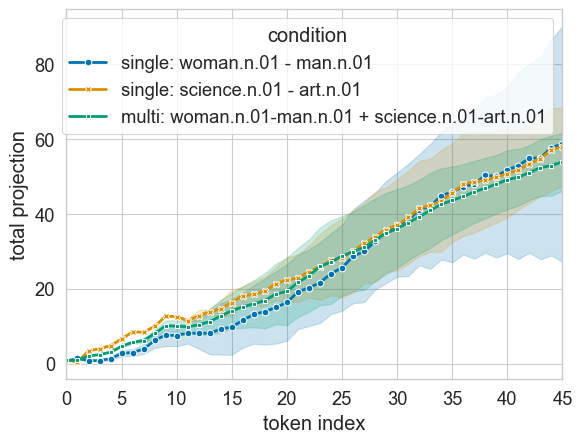

In [12]:
# combined probe: single-concept vs multi-concept modes
df_compare = pd.concat([df_single, df_multi], ignore_index=True)
lineplot_and_save("12_combined_probe", df_compare, x=X, y=Y, hue=HUE)

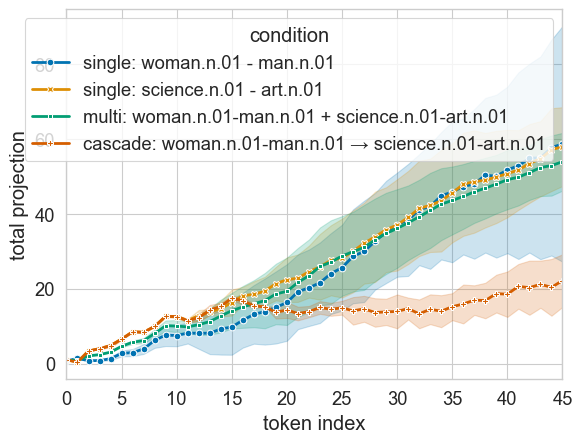

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df_cascade_q_plot = pd.DataFrame(probe_cascade_q.numpy()).melt(var_name=X, value_name=Y)
df_cascade_q_plot[HUE] = (
    f"cascade: {CONCEPT_PAIRS[0][0]}-{CONCEPT_PAIRS[0][1]}"
    f" → {CONCEPT_PAIRS[1][0]}-{CONCEPT_PAIRS[1][1]}"
)

df_all = pd.concat([df_single, df_multi, df_cascade_q_plot], ignore_index=True)
lineplot_and_save("12_all_probes", df_all, x=X, y=Y, hue=HUE)

In [14]:
n_show = 5

print("=== No steering ===")
for t in baseline_texts[:n_show]:
    print(" -", t)

for pair, (texts, _) in single_results.items():
    print(f"\n=== Single: {pair[0]} - {pair[1]} ===")
    for t in texts[:n_show]:
        print(" -", t)

print("\n=== Multi-concept ===")
for t in texts_multi_c[:n_show]:
    print(" -", t)

print(f"\n=== Cascade: [{c1_label}] → [{c2_label}] ===")
for t in texts_cascade_q[:n_show]:
    print(" -", t)

=== No steering ===
 - <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. Men can be very supportive and loving partners, always there to lend a helping hand and make their loved ones feel secure and loved.
 - <|start_header_id|>user<|end_header_id|>What women can be?<|start_header_id|>assistant<|end_header_id|>1. A woman can be a mother.

=== Single: woman.n.01 - man.n.01 ===
 - <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. A man can make you feel like a queen, and treat her like a goddess.

1-1-1-4-4-4-4-4-
 - <|start_header_id|>user<|end_header_id|>What women can be?<|start_header_id|>assistant<|end_header_id|>1. A woman is the one, the very essence, the embodiment, the personified, the feminine, the divine, the sacred, the mysterious, or simply, the

=== Single: science.n.01 - art.n.01 ===
 - <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assist

100%|██████████| 1/1 [00:09<00:00,  9.13s/it]


=== Multi-concept steering ===
 - <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. A man can become the head, but a man cannot rule a family without his head, his mother, his father, his wife, his children, his friends,
 - <|start_header_id|>user<|end_header_id|>What women can be?<|start_header_id|>assistant<|end_header_id|>1. Mother 
A mother is the most important and caring figure of the house, especially when the family is a small nuclear family, where the father works and the child is


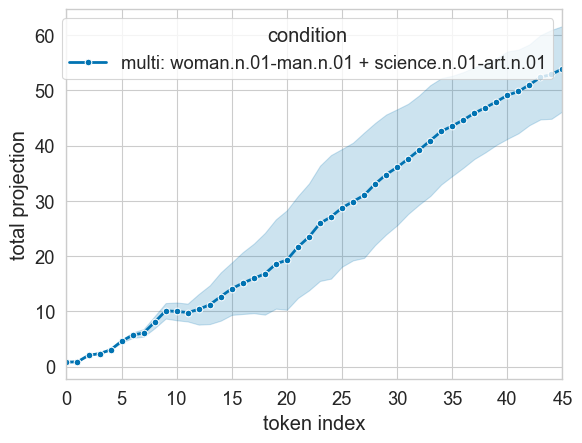

In [15]:
texts_multi, probe_multi = fur.quick_generate_with_topk_multi_guide(
    inputs,
    guides=CONCEPT_PAIRS,
    min_lemmas_per_synset=MIN_LEMMAS,
    max_token_count=MAX_TOKENS,
    k=K,
    steps=STEPS,
    batch_size=BATCH_SIZE,
)

n_show = 5
print("=== Multi-concept steering ===")
for t in texts_multi[:n_show]:
    print(" -", t)

df_multi_new = pd.DataFrame(probe_multi.numpy()).melt(var_name=X, value_name=Y)
df_multi_new[HUE] = "multi: " + " + ".join(f"{a}-{b}" for a, b in CONCEPT_PAIRS)
lineplot_and_save("12_multi_probe", df_multi_new, x=X, y=Y, hue=HUE)

### Section G — Cascade steering

Two-phase approach: beam search is driven by `c1` at every step (same as single-concept CGD),
then the `k` surviving beams are re-scored by `c2` and the single best is returned.
This separates *generation diversity* (controlled by c1) from *final selection* (controlled by c2).

100%|██████████| 1/1 [00:09<00:00,  9.69s/it]


=== Cascade: beam search on [woman.n.01 - man.n.01], final selection by [science.n.01 - art.n.01] ===
 - <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. A man can make you feel like a queen, and treat her like a goddess.

1-1-1-4-4-4-4-4


 - <|start_header_id|>user<|end_header_id|>What women can be?<|start_header_id|>assistant<|end_header_id|>1. A woman is the one, the very essence, the embodiment, the personified, the feminine, the divine, the sacred, the mysterious, or simply, the


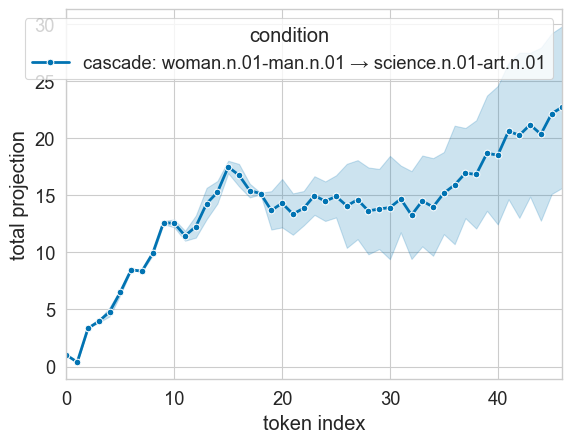

In [16]:
c1_synset, c2_synset = CONCEPT_PAIRS[0], CONCEPT_PAIRS[1]
c1 = fur.get_concept(c1_synset[0], MIN_LEMMAS, MAX_TOKENS) - fur.get_concept(c1_synset[1], MIN_LEMMAS, MAX_TOKENS)
c2 = fur.get_concept(c2_synset[0], MIN_LEMMAS, MAX_TOKENS) - fur.get_concept(c2_synset[1], MIN_LEMMAS, MAX_TOKENS)

texts_cascade, probe_cascade = fur.generate_with_topk_cascade_guide(
    inputs,
    c1,
    c2,
    k=K,
    steps=STEPS,
    batch_size=BATCH_SIZE,
)

n_show = 5
print(f"=== Cascade: beam search on [{c1_synset[0]} - {c1_synset[1]}], final selection by [{c2_synset[0]} - {c2_synset[1]}] ===")
for t in texts_cascade[:n_show]:
    print(" -", t)

df_cascade = pd.DataFrame(probe_cascade.numpy()).melt(var_name=X, value_name=Y)
df_cascade[HUE] = f"cascade: {c1_synset[0]}-{c1_synset[1]} → {c2_synset[0]}-{c2_synset[1]}"
lineplot_and_save("12_cascade_probe", df_cascade, x=X, y=Y, hue=HUE)

### Section H — Average subspace steering (Fréchet mean)

Each concept pair `(A, B)` produces a directional frame `A − B`. `Concept.average` then computes the Fréchet mean of all those frames on the Stiefel manifold via `solve_procrustes(F1 + F2 + ... + Fn)`, yielding a single frame geometrically equidistant from all inputs. This is used as the guide for a single top-k beam search — no blending of scores, no alternation, just one averaged subspace.

100%|██████████| 1/1 [00:09<00:00,  9.36s/it]


=== Average subspace steering ===
 - <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. A man can become the head, but a man cannot rule a family without his head, his mother, his father, his wife, his children, his friends,
 - <|start_header_id|>user<|end_header_id|>What women can be?<|start_header_id|>assistant<|end_header_id|>1. Mother 
A mother is the most important and caring figure of the house, especially when the family is a small nuclear family, where the father works and the child is


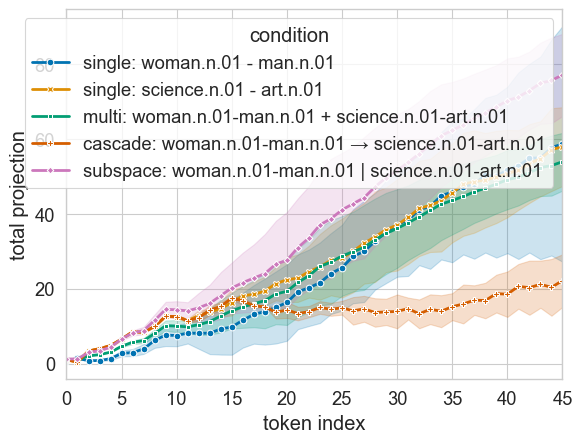

In [17]:
texts_subspace, probe_subspace = fur.quick_generate_with_topk_subspace_guide(
    inputs,
    guides=CONCEPT_PAIRS,
    min_lemmas_per_synset=MIN_LEMMAS,
    max_token_count=MAX_TOKENS,
    k=K,
    steps=STEPS,
    batch_size=BATCH_SIZE,
)

n_show = 5
print("=== Average subspace steering ===")
for t in texts_subspace[:n_show]:
    print(" -", t)

df_subspace = pd.DataFrame(probe_subspace.numpy()).melt(var_name=X, value_name=Y)
df_subspace[HUE] = "subspace: " + " | ".join(f"{a}-{b}" for a, b in CONCEPT_PAIRS)

df_all_h = pd.concat([df_single, df_multi, df_cascade_q_plot, df_subspace], ignore_index=True)
lineplot_and_save("12_all_probes_with_subspace", df_all_h, x=X, y=Y, hue=HUE)